In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [35]:
df=pd.read_csv("SOCR-HeightWeight.csv")

In [36]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [37]:
df = df.drop(columns=["Index"])


df = df.rename(columns={
    "Height(Inches)": "Height",
    "Weight(Pounds)": "Weight"
})

df["Height"] = df["Height"].round().astype(int)
df["Weight"] = df["Weight"].round().astype(int)


In [38]:
df.head()

,Height,Weight
0,66,113
1,72,136
2,69,153
3,68,142
4,68,144


Text(0.5, 1.0, 'Relationship Between Weight and Height')

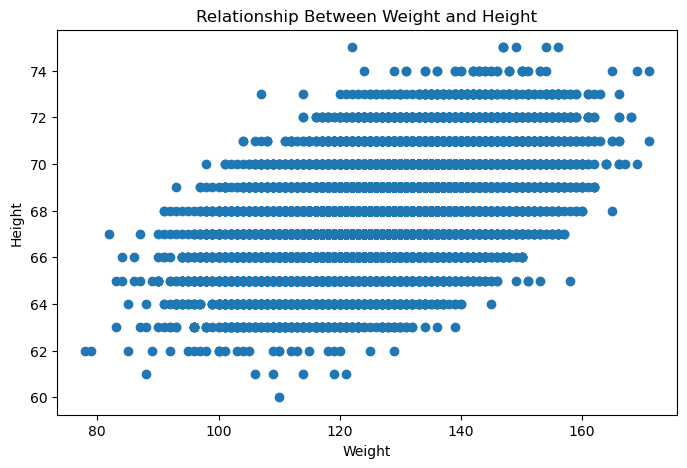

In [39]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Weight'], df['Height'])

plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Relationship Between Weight and Height")

In [40]:
x= df[['Weight']] ##independent feature
y=df['Height'] ##dependent feature

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [43]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((20000, 1), (5000, 1), (20000,), (5000,))

In [44]:
from sklearn.preprocessing import StandardScaler

In [45]:
scaler = StandardScaler()

In [46]:
x_train.head()

,Weight
23311,111
23623,127
1020,140
12645,133
1533,115


In [48]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

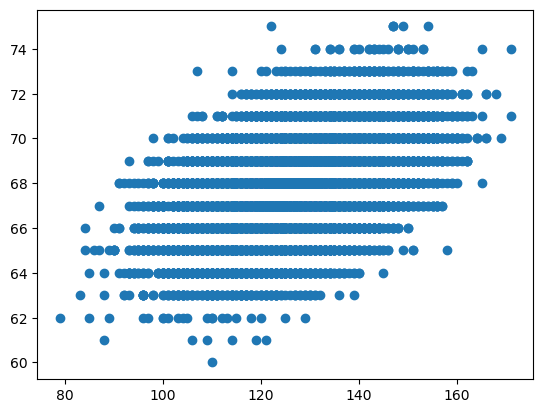

In [49]:
plt.scatter(x_train,y_train)

In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
regressor=LinearRegression()

In [52]:
regressor.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
print("The slope or coefficient of weight is ",regressor.coef_)
print("Intercept:",regressor.intercept_)

The slope or coefficient of weight is  [0.08165832]
Intercept: 57.61511359038697


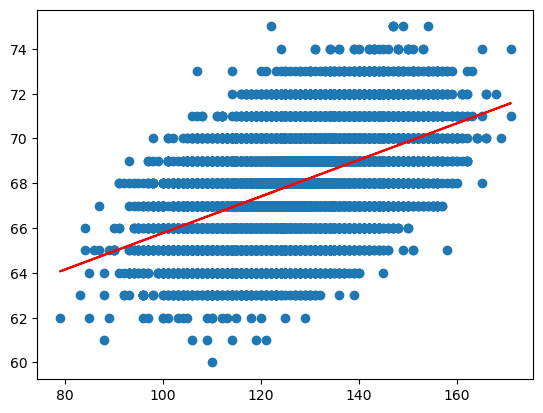

In [54]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regressor.predict(x_train),'r')

In [55]:
y_pred_test=regressor.predict(x_test)


In [56]:
y_pred_test,y_test

(array([68.55732873, 66.76084565, 68.72064537, ..., 69.12893698,
        68.23069544, 68.63898705], shape=(5000,)),
 6868     68
 24016    68
 9668     68
 13640    69
 14018    69
          ..
 8670     69
 11839    67
 4013     69
 21147    67
 695      71
 Name: Height, Length: 5000, dtype: int64)

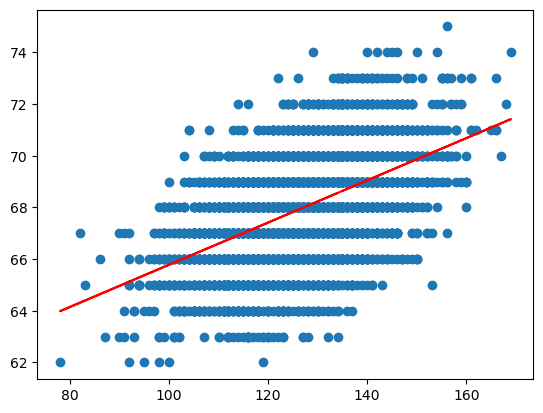

In [57]:
plt.scatter(x_test,y_test)
plt.plot(x_test,regressor.predict(x_test),'r')

In [58]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [59]:
mse=mean_squared_error(y_test,y_pred_test)
mae=mean_absolute_error(y_test,y_pred_test)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

2.8228059829281187
1.337852759866955
1.6801208239076495


In [60]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred_test)

In [61]:
score

0.25223504296351473

In [62]:
1- (1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.2520854301269728

In [64]:
weight = pd.DataFrame([[150]], columns=["Weight"])

scaled_weight = scaler.transform(weight)

prediction = regressor.predict(scaled_weight)

print(prediction)

[57.77598128]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


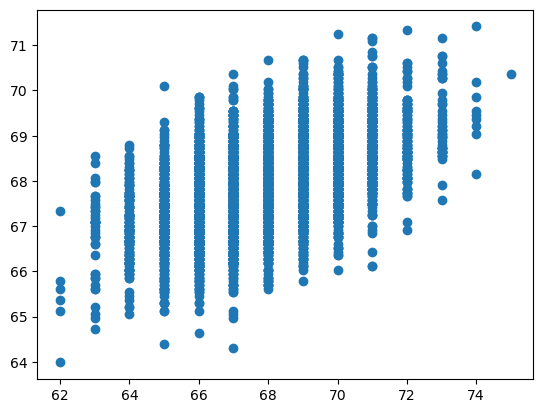

In [65]:
plt.scatter(y_test,y_pred_test)

In [66]:
residuals=y_test-y_pred_test
residuals

6868    -0.557329
24016    1.239154
9668    -0.720645
13640    1.095938
14018    3.219054
           ...   
8670     0.116038
11839    0.810763
4013    -0.128937
21147   -1.230695
695      2.361013
Name: Height, Length: 5000, dtype: float64

C:\Users\Haemimont\AppData\Local\Temp\ipykernel_8572\3905197135.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

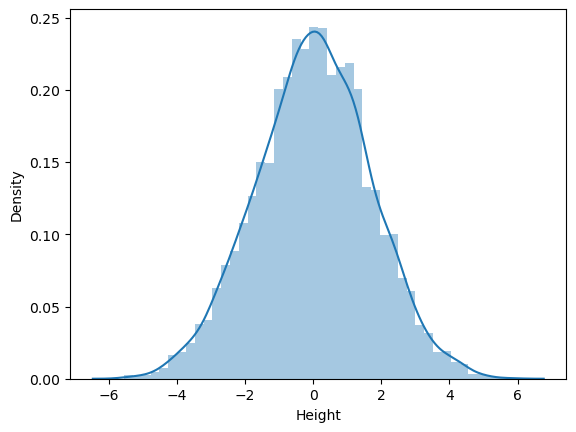

In [68]:
import seaborn as sns
sns.distplot(residuals,kde=True)

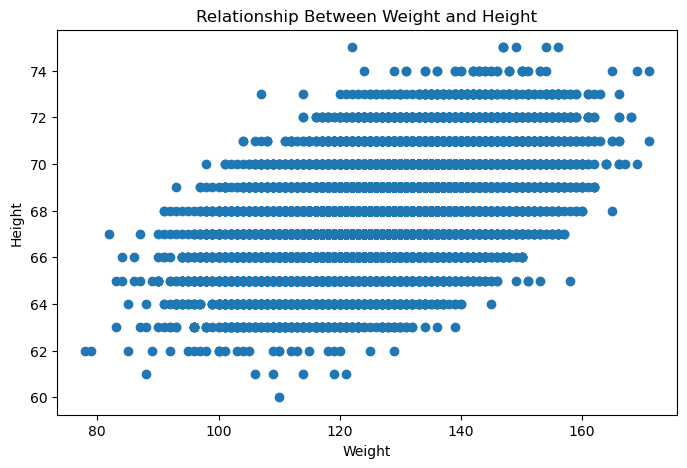

Coefficient: [0.08165832]
Intercept: 57.61511359038697
MAE: 1.337852759866955
MSE: 2.8228059829281187
RMSE: 1.6801208239076495
R2 Score: 0.25223504296351473
Adjusted R2: 0.2520854301269728


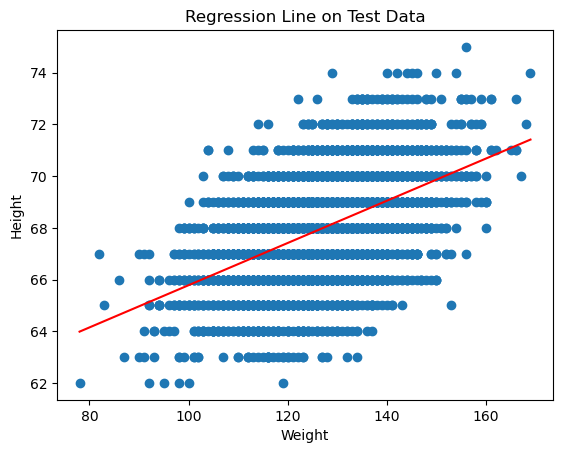

Predicted height for weight 150: [69.86386188]


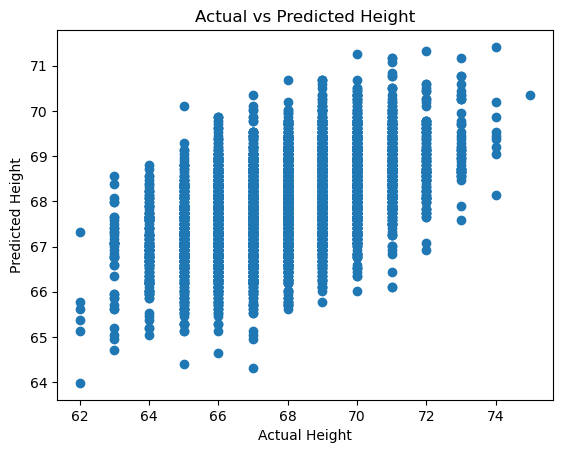

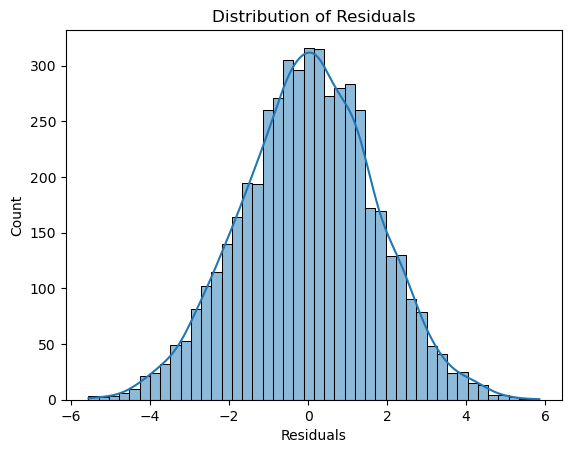

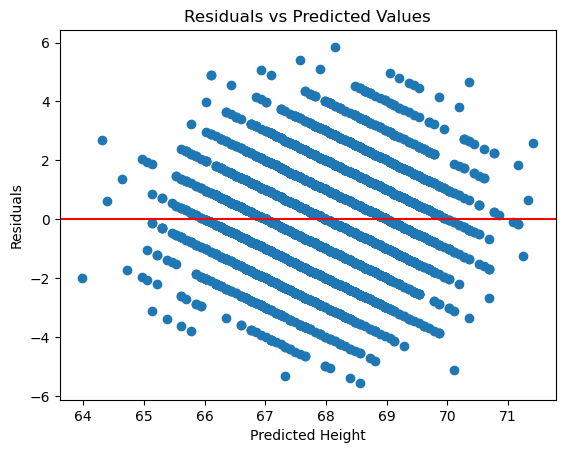

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("SOCR-HeightWeight.csv")

df = df.drop(columns=["Index"])

df = df.rename(columns={
    "Height(Inches)": "Height",
    "Weight(Pounds)": "Weight"
})

df["Height"] = df["Height"].round().astype(int)
df["Weight"] = df["Weight"].round().astype(int)

X = df[["Weight"]]
y = df["Height"]

plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Relationship Between Weight and Height")
plt.show()

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

regressor = LinearRegression()
regressor.fit(x_train, y_train)

print("Coefficient:", regressor.coef_)
print("Intercept:", regressor.intercept_)

y_pred_test = regressor.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
print("Adjusted R2:", adjusted_r2)

plt.scatter(x_test, y_test)

x_line = np.linspace(x_test.min(), x_test.max(), 100)
x_line_df = pd.DataFrame(x_line, columns=["Weight"])

plt.plot(x_line_df, regressor.predict(x_line_df), color="red")

plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Regression Line on Test Data")
plt.show()

weight = pd.DataFrame([[150]], columns=["Weight"])
prediction = regressor.predict(weight)

print("Predicted height for weight 150:", prediction)

plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Height")
plt.ylabel("Predicted Height")
plt.title("Actual vs Predicted Height")
plt.show()

residuals = y_test - y_pred_test

sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

plt.scatter(y_pred_test, residuals)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Height")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()